# LECTURE 23
**Topic:** Linear Convolution of Sequences and Vectors; Linear Convolution as Circular Convolution; Block Convolution  
**Textbook References:** Sections 4.6, 4.7.1, 4.7.2, 4.7.4

---

## Key Points

- **Linear convolution** of sequences: $y[n]=(h*x)[n]=\sum_{k=-\infty}^{\infty}h[k]x[n-k]$
- $h[\cdot]$: impulse response (response to unit impulse $\delta[\cdot]$)
- For vectors of length $K$ and $L$: output has length $K+L-1$
- **Linear via circular:** $b*s = [b;\mathbf{0}_{L-1}]\circledast[s;\mathbf{0}_{K-1}]$ (zero-pad to $K+L-1$)
- **Block convolution:** $b*[s^{(1)};s^{(2)}]=[b*s^{(1)};\mathbf{0}_{L_2}]+[\mathbf{0}_{L_1};b*s^{(2)}]$


---
## Theory and Examples

### 1–2. Impulse Response and Convolution

The **unit impulse:** $\delta[n]=1$ for $n=0$, else $0$.

The impulse response $h[\cdot]$ is the filter's output when input is $\delta[\cdot]$. Then for any input $x$:
$$y[n]=\sum_{k=-\infty}^{\infty}h[k]x[n-k]=(h*x)[n]$$

**Why?** Decompose $x[\cdot]=\sum_k x[k]\delta[\cdot-k]$. By linearity and time-invariance:
$y[\cdot]=\sum_k x[k]h[\cdot-k]$

### 3. Convolution is Commutative

$h*x = x*h$ (substitute $k'=n-k$).

### 5. Steps for Computing Convolution

For a fixed $n$: (1) reverse one sequence, (2) shift by $n$, (3) compute dot product.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Unit impulse response
b=np.array([2.,-1.,1.,-2.])
delta=np.zeros(20); delta[0]=1
h=np.convolve(b,delta)[:20]
print(f'Filter b = {b}')
print(f'Impulse response h = {h[:8]}...')
print(f'h[0:3] = b? {np.allclose(h[:len(b)],b)}')

# Example 6: linear convolution
b_ex=np.array([2.,-1.,1.,-2.])
x_ex=np.array([1.,2.,3.,-1.])
y_conv=np.convolve(b_ex,x_ex)
print(f'\nLinear convolution:')
print(f'b = {b_ex}')
print(f'x = {x_ex}')
print(f'b*x = {y_conv}  (length K+L-1={len(b_ex)+len(x_ex)-1})')
print('Expected: [2,3,5,-5,0,-7,2]')

# Verify step by step (table from lecture)
print('\nStep-by-step (slide n-k):')
N_out=len(b_ex)+len(x_ex)-1
y_manual=np.zeros(N_out)
for n in range(N_out):
    val=0
    for k in range(len(b_ex)):
        if 0<=n-k<len(x_ex):
            val+=b_ex[k]*x_ex[n-k]
    y_manual[n]=val
print(f'Manual: {y_manual}')
print(f'Match? {np.allclose(y_manual,y_conv)}')

Filter b = [ 2. -1.  1. -2.]
Impulse response h = [ 2. -1.  1. -2.  0.  0.  0.  0.]...
h[0:3] = b? True

Linear convolution:
b = [ 2. -1.  1. -2.]
x = [ 1.  2.  3. -1.]
b*x = [ 2.  3.  5. -5.  0. -7.  2.]  (length K+L-1=7)
Expected: [2,3,5,-5,0,-7,2]

Step-by-step (slide n-k):
Manual: [ 2.  3.  5. -5.  0. -7.  2.]
Match? True


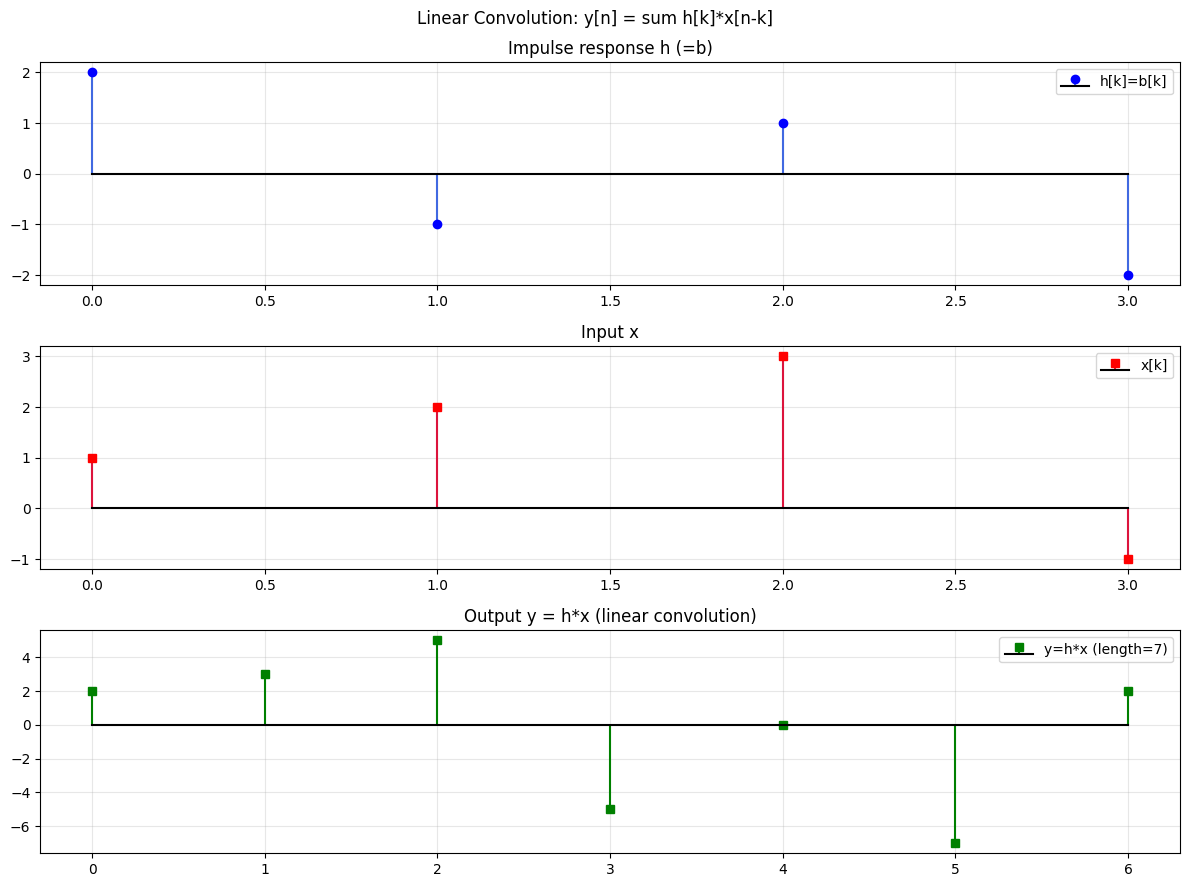

In [2]:
# Visualize convolution
b_v=np.array([2.,-1.,1.,-2.])
s_v=np.array([1.,2.,3.,-1.])
K=len(b_v); L=len(s_v)

fig,axes=plt.subplots(3,1,figsize=(12,9))

axes[0].stem(range(K),b_v,linefmt='royalblue',markerfmt='bo',basefmt='k',label='h[k]=b[k]')
axes[0].set_title('Impulse response h (=b)'); axes[0].legend(); axes[0].grid(True,alpha=0.3)

axes[1].stem(range(L),s_v,linefmt='crimson',markerfmt='rs',basefmt='k',label='x[k]')
axes[1].set_title('Input x'); axes[1].legend(); axes[1].grid(True,alpha=0.3)

y_v=np.convolve(b_v,s_v)
axes[2].stem(range(len(y_v)),y_v,linefmt='green',markerfmt='gs',basefmt='k',label=f'y=h*x (length={K+L-1})')
axes[2].set_title('Output y = h*x (linear convolution)'); axes[2].legend(); axes[2].grid(True,alpha=0.3)

plt.suptitle('Linear Convolution: y[n] = sum h[k]*x[n-k]', fontsize=12)
plt.tight_layout(); plt.show()

---
### 7–9. Linear Convolution of Vectors and Circular Implementation

For vectors $b$ (length $K$) and $s$ (length $L$):
$$b*s = \text{output}\;y[0:K+L-2]$$

**Via circular convolution** (zero-pad both to $N=K+L-1$):
$$b*s = [b;\mathbf{0}_{L-1}]\circledast[s;\mathbf{0}_{K-1}]$$

Or equivalently, using DFT:
```python
N = K + L - 1
B = fft(b, N); S = fft(s, N)
y = ifft(B * S)  # linear convolution
```

### 11–12. Block Convolution

Split long input $s=[s^{(1)};s^{(2)}]$ into blocks of length $L$:
$$b*[s^{(1)};s^{(2)}]=[b*s^{(1)};\mathbf{0}_{L_2}]+[\mathbf{0}_{L_1};b*s^{(2)}]$$

Note: the output segments **overlap** by $K-1$ samples (the filter order $M=K-1$).


Linear convolution via circular convolution (zero-padded):
  np.convolve:    [ 2.  3.  5. -5.  0. -7.  2.]
  IFFT(B*S):      [ 2.  3.  5. -5.  0. -7.  2.]
  Match? True

Block convolution (L=6):
  b*s^(1) = [  1.  -5.   6.   2. -19. -23.  -2.  10.  -2.]
  b*s^(2) = [  7. -16. -35.  -8.  -8.  -9.  18.  11.  -4.]
  Combined: [  1.  -5.   6.   2. -19. -23.   5.  -6. -37.  -8.  -8.  -9.  18.  11.
  -4.]
  Direct:   [  1.  -5.   6.   2. -19. -23.   5.  -6. -37.  -8.  -8.  -9.  18.  11.
  -4.]
  Match? True


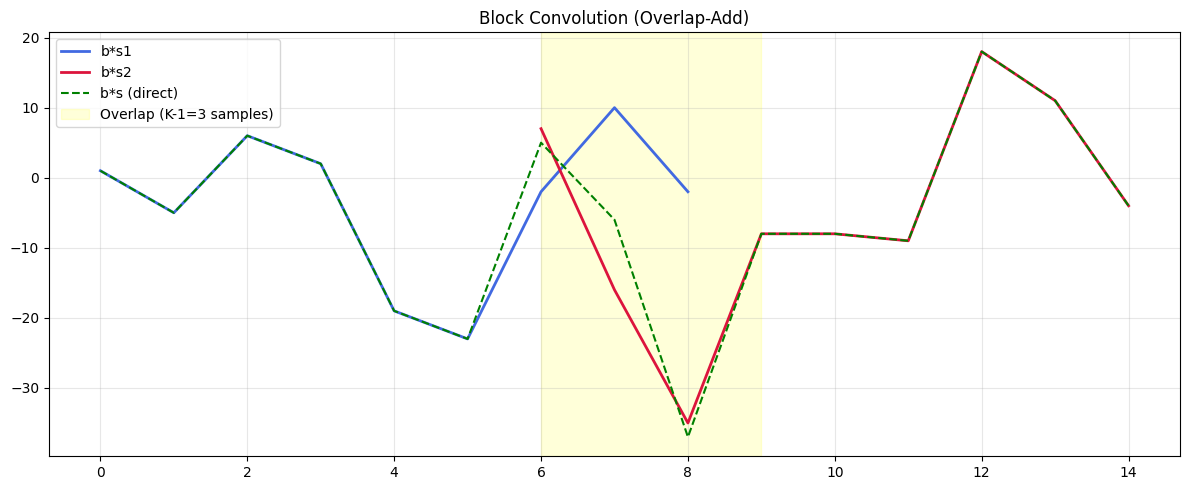

In [3]:
b_lc=np.array([2.,-1.,1.,-2.])
s_lc=np.array([1.,2.,3.,-1.])
K=len(b_lc); L=len(s_lc); N=K+L-1

# Method 1: np.convolve
y1=np.convolve(b_lc,s_lc)

# Method 2: circular convolution (zero-pad to N)
B=np.fft.fft(b_lc,N); S2=np.fft.fft(s_lc,N)
y2=np.fft.ifft(B*S2).real

print('Linear convolution via circular convolution (zero-padded):')
print(f'  np.convolve:    {y1}')
print(f'  IFFT(B*S):      {y2.round(6)}')
print(f'  Match? {np.allclose(y1,y2)}')

# Block convolution example
b_bc=np.array([1.,-3.,-3.,1.])
s_bc=np.array([1.,-2.,3.,4.,4.,-2.,7.,5.,1.,3.,-1.,-4.])
K_bc=len(b_bc); L_block=6
s1=s_bc[:L_block]; s2=s_bc[L_block:]

b_conv_s1=np.convolve(b_bc,s1)
b_conv_s2=np.convolve(b_bc,s2)

# Combine
L1=len(b_conv_s1); L2=len(b_conv_s2)
out_len=len(s_bc)+K_bc-1
y_block=np.zeros(out_len)
y_block[:L1]+=b_conv_s1
y_block[L_block:L_block+L2]+=b_conv_s2

y_direct=np.convolve(b_bc,s_bc)

print(f'\nBlock convolution (L={L_block}):')
print(f'  b*s^(1) = {b_conv_s1}')
print(f'  b*s^(2) = {b_conv_s2}')
print(f'  Combined: {y_block}')
print(f'  Direct:   {y_direct}')
print(f'  Match? {np.allclose(y_block,y_direct)}')

# Visualize overlap-add
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(range(L1),b_conv_s1,'royalblue',lw=2,label='b*s1')
ax.plot(range(L_block,L_block+L2),b_conv_s2,'crimson',lw=2,label='b*s2')
ax.plot(range(len(y_direct)),y_direct,'green',lw=1.5,ls='--',label='b*s (direct)')
ax.axvspan(L_block,L1,alpha=0.15,color='yellow',label=f'Overlap (K-1={K_bc-1} samples)')
ax.set_title('Block Convolution (Overlap-Add)'); ax.legend(); ax.grid(True,alpha=0.3)
plt.tight_layout(); plt.show()

---
## Summary

| Concept | Formula |
|---|---|
| Linear convolution | $y[n]=\sum_k h[k]x[n-k]$ |
| Output length | $K+L-1$ for inputs of lengths $K,L$ |
| Linear via circular | zero-pad to $K+L-1$, then circular conv |
| Via FFT | `ifft(fft(b,N)*fft(s,N))`, $N=K+L-1$ |
| Block conv | overlap by $K-1$ samples |

### Mistakes to Avoid
1. Zero-pad to $N=K+L-1$, NOT just $\max(K,L)$ — otherwise circular wrap-around ruins the result.
2. In block convolution, the overlapping region (length $K-1$) must be **added**, not discarded.
3. Linear convolution is **not** the same as circular convolution unless properly zero-padded.
